Font in use: Times New Roman
Saved: /Users/nandan/Desktop/CTCs/IBM/method1_fidelity_vs_theta.png
Saved: /Users/nandan/Desktop/CTCs/IBM/method1_fidelity_vs_theta.pdf


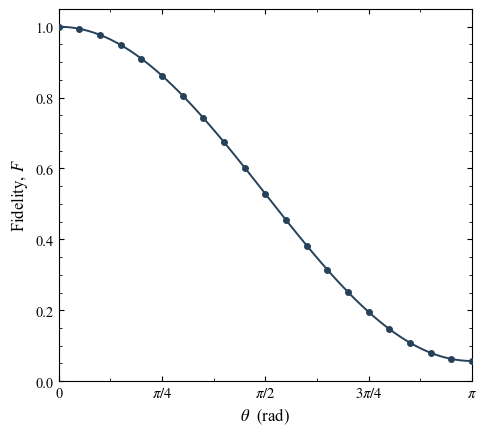

In [2]:
"""
PRX-style single-panel figure: Method 1 fidelity vs Rx(θ) perturbation on E.

Square aspect ratio to match the scatter plot in the three-panel composite.
Tweakables grouped at the top.  Run:
    python method1_fidelity_vs_theta.py

Outputs:
    method1_fidelity_vs_theta.png   (600 dpi)
    method1_fidelity_vs_theta.pdf   (vector, for LaTeX)

------------------------------------------------------------------
FONT NOTES (project standard)
------------------------------------------------------------------
Tries to use real Times New Roman if available; falls back to STIX
Two Text (a Times look-alike that ships with matplotlib).
Linux users may need: `sudo apt install msttcorefonts-installer`
followed by `rm -rf ~/.cache/matplotlib`.

------------------------------------------------------------------
INPUT
------------------------------------------------------------------
Expects a .npz file with keys: thetas, F.
  - thetas: 1D array, the R_x angle θ in radians (here 0..π, 81 points)
  - F     : 1D array of message fidelities at each θ
"""
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.ticker import FixedLocator, FuncFormatter, MultipleLocator

# ============================================================
# Tweakable parameters
# ============================================================
INPUT_NPZ   = "method1_data.npz"
OUT_BASE    = "/Users/nandan/Desktop/CTCs/IBM/method1_fidelity_vs_theta"

# Square-ish, matching the scatter plot's footprint
FIGSIZE_IN  = (5.0, 4.5)

LINE_COLOR  = "#26415a"   # slate-navy (project standard for Method 1)
MARKER      = "o"
# TITLE_TEXT  = r"Method 1: $R_x(\theta)$ on $E$"
SHOW_TITLE  = True        # set False to push title into caption

# ============================================================
# Font selection: real Times if available, else STIX Two Text
# ============================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman"]
elif "Times" in installed:
    SERIF_STACK = ["Times"]
else:
    SERIF_STACK = ["STIX Two Text", "STIXGeneral", "DejaVu Serif"]

# ============================================================
# PRX rcParams — sized for the larger figure
# ============================================================
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          SERIF_STACK,
    "mathtext.fontset":    "stix",
    "font.size":           11,
    "axes.labelsize":      12,
    "axes.titlesize":      12,
    "xtick.labelsize":     10.5,
    "ytick.labelsize":     10.5,
    "legend.fontsize":     10,
    "axes.linewidth":      0.8,
    "xtick.major.width":   0.8,
    "ytick.major.width":   0.8,
    "xtick.minor.width":   0.6,
    "ytick.minor.width":   0.6,
    "xtick.major.size":    3.5,
    "ytick.major.size":    3.5,
    "xtick.minor.size":    2.0,
    "ytick.minor.size":    2.0,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,
    "ytick.right":         True,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# ============================================================
# Load data
# ============================================================
d = np.load(INPUT_NPZ)
thetas = d["thetas"]
F_vals = d["F"]

# ============================================================
# Helpers
# ============================================================
def pi_fmt(val, _pos):
    if np.isclose(val, 0):           return "0"
    if np.isclose(val, np.pi/4):     return r"$\pi/4$"
    if np.isclose(val, np.pi/2):     return r"$\pi/2$"
    if np.isclose(val, 3*np.pi/4):   return r"$3\pi/4$"
    if np.isclose(val, np.pi):       return r"$\pi$"
    return ""

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE_IN)

ax.plot(thetas, F_vals,
        color=LINE_COLOR, lw=1.4,
        marker=MARKER, markersize=4,
        markerfacecolor=LINE_COLOR, markeredgecolor=LINE_COLOR,
        markevery=4, zorder=3)

# ---- axes ----
ax.set_xlim(0, np.pi)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_locator(FixedLocator([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]))
ax.xaxis.set_major_formatter(FuncFormatter(pi_fmt))
ax.xaxis.set_minor_locator(FixedLocator(np.arange(0, np.pi + 1e-9, np.pi/8)))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xlabel(r"$\theta$  (rad)")
ax.set_ylabel(r"Fidelity, $F$")

# if SHOW_TITLE:
#     ax.set_title(TITLE_TEXT, pad=8)

plt.tight_layout()

# ============================================================
# Save
# ============================================================
fig.savefig(f"{OUT_BASE}.png", dpi=600, bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.pdf",            bbox_inches="tight")
print("Font in use:", mpl.rcParams["font.serif"][0])
print(f"Saved: {OUT_BASE}.png")
print(f"Saved: {OUT_BASE}.pdf")

Font in use: Times New Roman
Saved: /Users/nandan/Desktop/CTCs/IBM/method2_fidelity_vs_theta.png
Saved: /Users/nandan/Desktop/CTCs/IBM/method2_fidelity_vs_theta.pdf


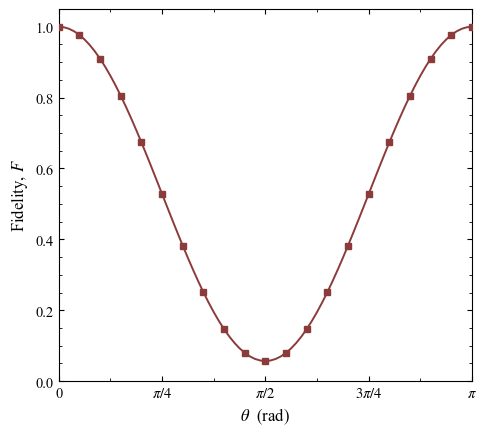

In [3]:
"""
PRX-style single-panel figure: Method 2 fidelity vs Rx(θ) perturbation
with conjugate sandwich on E and M.

Same square aspect as method1_fidelity_vs_theta.py so the three panels
in the composite figure look the same size.

Run:
    python method2_fidelity_vs_theta.py

Outputs:
    method2_fidelity_vs_theta.png   (600 dpi)
    method2_fidelity_vs_theta.pdf   (vector, for LaTeX)

------------------------------------------------------------------
FONT NOTES (project standard)
------------------------------------------------------------------
Tries to use real Times New Roman if available; falls back to STIX
Two Text (a Times look-alike that ships with matplotlib).
Linux users may need: `sudo apt install msttcorefonts-installer`
followed by `rm -rf ~/.cache/matplotlib`.

------------------------------------------------------------------
INPUT
------------------------------------------------------------------
Expects a .npz file with keys: thetas, F.
"""
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.ticker import FixedLocator, FuncFormatter, MultipleLocator

# ============================================================
# Tweakable parameters
# ============================================================
INPUT_NPZ   = "method2_data.npz"
OUT_BASE    = "/Users/nandan/Desktop/CTCs/IBM/method2_fidelity_vs_theta"

FIGSIZE_IN  = (5.0, 4.5)

LINE_COLOR  = "#8c3b3b"   # brick (project standard for Method 2)
MARKER      = "s"         # square — distinguishes from Method 1's circles
TITLE_TEXT  = r"Method 2: conjugate sandwich on $E,\,M$"
SHOW_TITLE  = False

# ============================================================
# Font selection
# ============================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman"]
elif "Times" in installed:
    SERIF_STACK = ["Times"]
else:
    SERIF_STACK = ["STIX Two Text", "STIXGeneral", "DejaVu Serif"]

# ============================================================
# PRX rcParams — sized for the larger figure
# ============================================================
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          SERIF_STACK,
    "mathtext.fontset":    "stix",
    "font.size":           11,
    "axes.labelsize":      12,
    "axes.titlesize":      12,
    "xtick.labelsize":     10.5,
    "ytick.labelsize":     10.5,
    "legend.fontsize":     10,
    "axes.linewidth":      0.8,
    "xtick.major.width":   0.8,
    "ytick.major.width":   0.8,
    "xtick.minor.width":   0.6,
    "ytick.minor.width":   0.6,
    "xtick.major.size":    3.5,
    "ytick.major.size":    3.5,
    "xtick.minor.size":    2.0,
    "ytick.minor.size":    2.0,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,
    "ytick.right":         True,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# ============================================================
# Load data
# ============================================================
d = np.load(INPUT_NPZ)
thetas = d["thetas"]
F_vals = d["F"]

# ============================================================
# Helpers
# ============================================================
def pi_fmt(val, _pos):
    if np.isclose(val, 0):           return "0"
    if np.isclose(val, np.pi/4):     return r"$\pi/4$"
    if np.isclose(val, np.pi/2):     return r"$\pi/2$"
    if np.isclose(val, 3*np.pi/4):   return r"$3\pi/4$"
    if np.isclose(val, np.pi):       return r"$\pi$"
    return ""

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE_IN)

ax.plot(thetas, F_vals,
        color=LINE_COLOR, lw=1.4,
        marker=MARKER, markersize=4,
        markerfacecolor=LINE_COLOR, markeredgecolor=LINE_COLOR,
        markevery=4, zorder=3)

# ---- axes ----
ax.set_xlim(0, np.pi)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_locator(FixedLocator([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]))
ax.xaxis.set_major_formatter(FuncFormatter(pi_fmt))
ax.xaxis.set_minor_locator(FixedLocator(np.arange(0, np.pi + 1e-9, np.pi/8)))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xlabel(r"$\theta$  (rad)")
ax.set_ylabel(r"Fidelity, $F$")

if SHOW_TITLE:
    ax.set_title(TITLE_TEXT, pad=8)

plt.tight_layout()

# ============================================================
# Save
# ============================================================
fig.savefig(f"{OUT_BASE}.png", dpi=600, bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.pdf",            bbox_inches="tight")
print("Font in use:", mpl.rcParams["font.serif"][0])
print(f"Saved: {OUT_BASE}.png")
print(f"Saved: {OUT_BASE}.pdf")

Font in use: Times New Roman
Saved: /Users/nandan/Desktop/CTCs/IBM/fig_hw_methods_panel.pdf
Saved: /Users/nandan/Desktop/CTCs/IBM/fig_hw_methods_panel.png


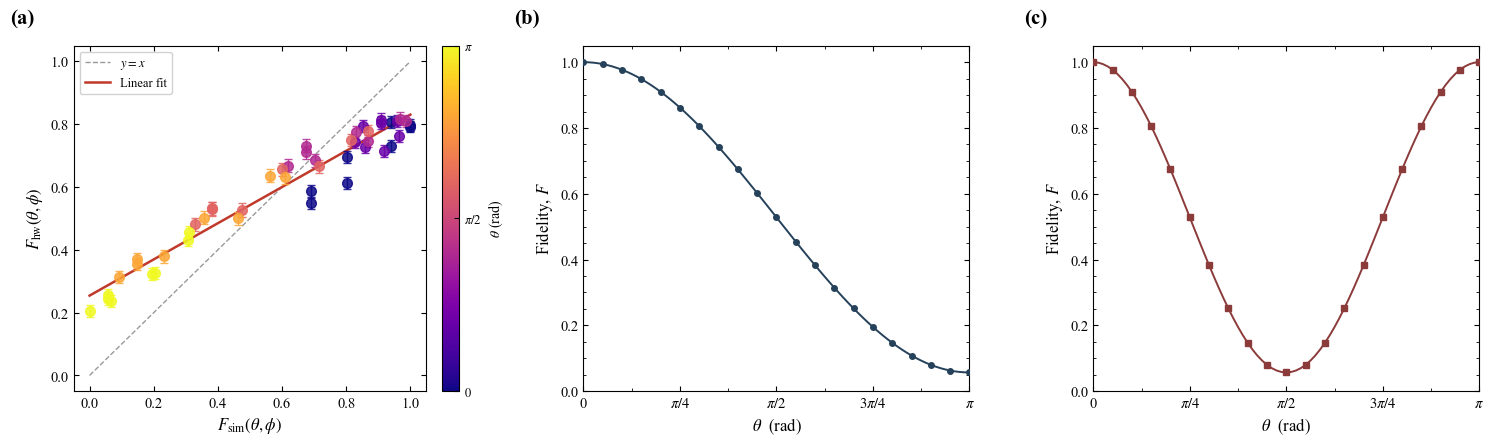

In [2]:
"""
Three-panel hardware/method comparison figure.

  (a) F_hw vs F_sim scatter with θ-coloured points, y=x reference, linear fit.
      Data: hw_sweep_results.json
  (b) Method 1: Fidelity vs Rx(θ) perturbation on E.
      Data: method1_data.npz   (keys: thetas, F)
  (c) Method 2: Fidelity vs Rx(θ) with conjugate sandwich on E, M.
      Data: method2_data.npz   (keys: thetas, F)

Layout matches the V.C panel style: three panels in one row, bold (a)/(b)/(c)
labels above the upper-left of each panel, Times New Roman throughout, no
per-panel titles.
"""
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import FixedLocator, FuncFormatter, MultipleLocator

# ============================================================
# Paths
# ============================================================
JSON_PATH    = "hw_sweep_results.json"
NPZ_METHOD1  = "method1_data.npz"
NPZ_METHOD2  = "method2_data.npz"
OUT_BASE     = "/Users/nandan/Desktop/CTCs/IBM/fig_hw_methods_panel"

# ============================================================
# Font selection: real Times if available, else STIX Two Text
# ============================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman"]
elif "Times" in installed:
    SERIF_STACK = ["Times"]
else:
    SERIF_STACK = ["STIX Two Text", "STIXGeneral", "DejaVu Serif"]

mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          SERIF_STACK,
    "mathtext.fontset":    "stix",
    "font.size":           11,
    "axes.labelsize":      12,
    "axes.titlesize":      12,
    "xtick.labelsize":     10.5,
    "ytick.labelsize":     10.5,
    "legend.fontsize":     10,
    "axes.linewidth":      0.8,
    "xtick.major.width":   0.8,
    "ytick.major.width":   0.8,
    "xtick.minor.width":   0.6,
    "ytick.minor.width":   0.6,
    "xtick.major.size":    3.5,
    "ytick.major.size":    3.5,
    "xtick.minor.size":    2.0,
    "ytick.minor.size":    2.0,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,
    "ytick.right":         True,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# Method colors (project standard)
M1_COLOR = "#26415a"   # slate-navy
M2_COLOR = "#8c3b3b"   # brick

# ============================================================
# Helpers
# ============================================================
def pi_fmt(val, _pos):
    if np.isclose(val, 0):           return "0"
    if np.isclose(val, np.pi/4):     return r"$\pi/4$"
    if np.isclose(val, np.pi/2):     return r"$\pi/2$"
    if np.isclose(val, 3*np.pi/4):   return r"$3\pi/4$"
    if np.isclose(val, np.pi):       return r"$\pi$"
    return ""


def panel_label(ax, label, x=-0.18, y=1.05):
    """Bold (a)/(b)/(c) tag in upper-left, outside the plot box."""
    ax.text(x, y, label,
            transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='bottom', ha='left')


# ============================================================
# Load data
# ============================================================
with open(JSON_PATH) as f:
    D = json.load(f)

F_hw   = np.array(D['F_hw'])
F_sim  = np.array(D['F_sim'])
F_lo   = np.array(D['F_hw_lo'])
F_hi   = np.array(D['F_hw_hi'])
thetas_hw = np.array(D['metadata']['thetas'])
phis_hw   = np.array(D['metadata']['phis'])
N_th, N_ph = len(thetas_hw), len(phis_hw)

d1 = np.load(NPZ_METHOD1)
thetas_m1, F_m1 = d1["thetas"], d1["F"]

d2 = np.load(NPZ_METHOD2)
thetas_m2, F_m2 = d2["thetas"], d2["F"]

# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# ----------------------------------------------------------------
# (a) Hardware vs simulator scatter, θ-coloured, with linear fit
# ----------------------------------------------------------------
ax = axes[0]
cmap_sc = plt.cm.plasma
# Broadcast theta across phi so every (θ,φ) point gets its θ-color
theta_grid = np.broadcast_to(thetas_hw[:, None], (N_th, N_ph))
theta_norm = (theta_grid - thetas_hw.min()) / (thetas_hw.max() - thetas_hw.min())

for i in range(N_th):
    for j in range(N_ph):
        ci_y = (F_hi[i, j] - F_lo[i, j]) / 2.0
        ax.errorbar(F_sim[i, j], F_hw[i, j],
                    yerr=ci_y,
                    fmt='o', color=cmap_sc(theta_norm[i, j]), ms=7,
                    elinewidth=1.0, capsize=3, capthick=1.0,
                    ecolor=cmap_sc(theta_norm[i, j]),
                    alpha=0.85, zorder=3)

ax.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.4, label='$y=x$')

c1, c0 = np.polyfit(F_sim.flatten(), F_hw.flatten(), 1)
x_ref  = np.linspace(0, 1, 100)
ax.plot(x_ref, c0 + c1 * x_ref, color='#C0392B', lw=1.8, label='Linear fit')

sm = plt.cm.ScalarMappable(
    cmap=cmap_sc, norm=plt.Normalize(thetas_hw.min(), thetas_hw.max()))
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'$\theta$ (rad)', fontsize=10)
cb.ax.tick_params(labelsize=9)
cb.set_ticks([0, np.pi / 2, np.pi])
cb.set_ticklabels([r'$0$', r'$\pi/2$', r'$\pi$'])

ax.set_xlabel(r'$F_{\rm sim}(\theta,\phi)$')
ax.set_ylabel(r'$F_{\rm hw}(\theta,\phi)$')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9, framealpha=0.9, loc='upper left')
# ax.grid(True, alpha=0.25, zorder=0)
panel_label(ax, '(a)')

# ----------------------------------------------------------------
# (b) Method 1 curve
# ----------------------------------------------------------------
ax = axes[1]
ax.plot(thetas_m1, F_m1,
        color=M1_COLOR, lw=1.4,
        marker='o', markersize=4,
        markerfacecolor=M1_COLOR, markeredgecolor=M1_COLOR,
        markevery=4, zorder=3)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_locator(FixedLocator([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]))
ax.xaxis.set_major_formatter(FuncFormatter(pi_fmt))
ax.xaxis.set_minor_locator(FixedLocator(np.arange(0, np.pi + 1e-9, np.pi/8)))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xlabel(r'$\theta$  (rad)')
ax.set_ylabel(r'Fidelity, $F$')
panel_label(ax, '(b)')

# ----------------------------------------------------------------
# (c) Method 2 curve
# ----------------------------------------------------------------
ax = axes[2]
ax.plot(thetas_m2, F_m2,
        color=M2_COLOR, lw=1.4,
        marker='s', markersize=4,
        markerfacecolor=M2_COLOR, markeredgecolor=M2_COLOR,
        markevery=4, zorder=3)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_locator(FixedLocator([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]))
ax.xaxis.set_major_formatter(FuncFormatter(pi_fmt))
ax.xaxis.set_minor_locator(FixedLocator(np.arange(0, np.pi + 1e-9, np.pi/8)))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xlabel(r'$\theta$  (rad)')
ax.set_ylabel(r'Fidelity, $F$')
panel_label(ax, '(c)')

fig.tight_layout()
fig.savefig(f"{OUT_BASE}.pdf", bbox_inches='tight', dpi=600)
fig.savefig(f"{OUT_BASE}.png", bbox_inches='tight', dpi=600)
print("Font in use:", mpl.rcParams["font.serif"][0])
print(f"Saved: {OUT_BASE}.pdf")
print(f"Saved: {OUT_BASE}.png")